## Data Loading

In [44]:
import pandas as pd

df = pd.read_csv("../data/001-breast-cancer.csv").set_index("id")
df = df.drop(columns=df.columns[-1])

df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820


## Original data before anything

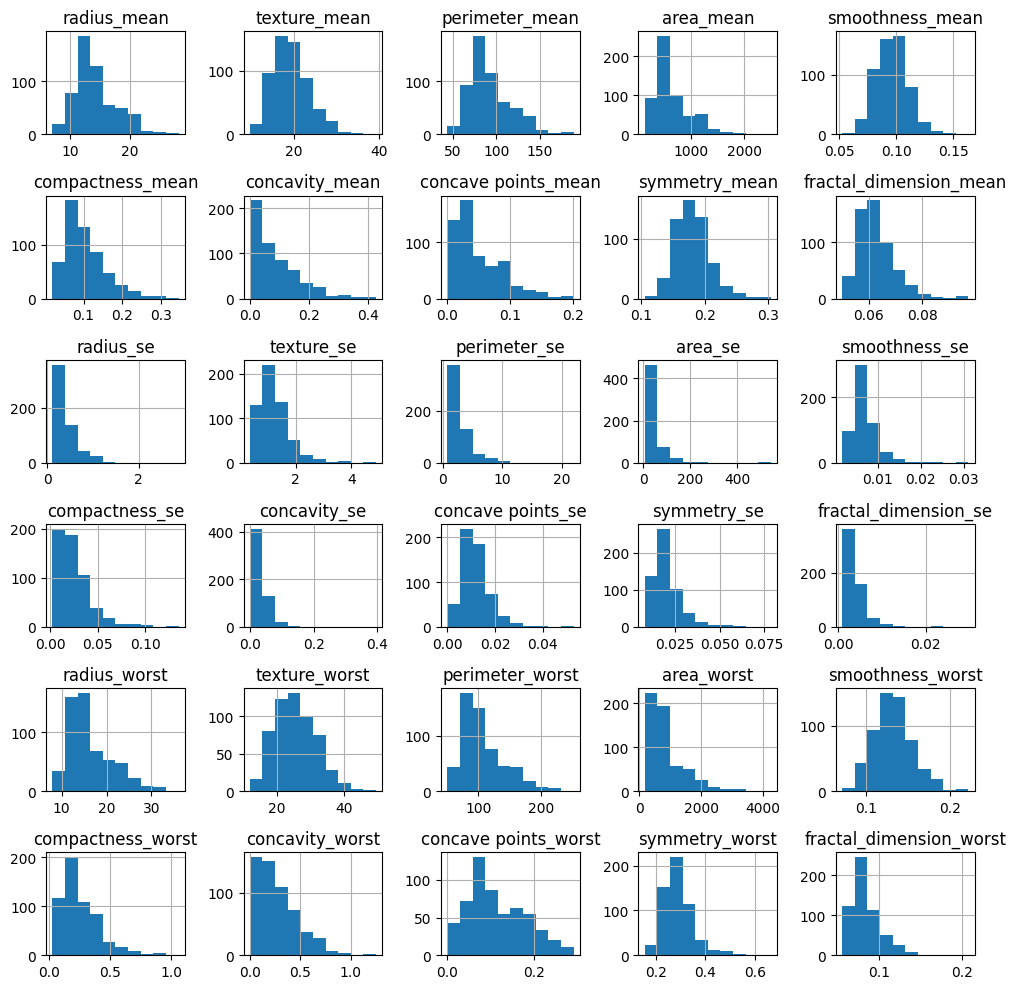

In [45]:
import matplotlib.pyplot as plt

x, y = df[df.columns[1:]], df[df.columns[0]]

x.hist(figsize=(10, 10))
plt.tight_layout()

## Model pipeline

In [86]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import VarianceThreshold

pipe1 = Pipeline([
    ("s1", StandardScaler()),
    ("pt", PowerTransformer(method="yeo-johnson")),
    ("s2", StandardScaler()),
    ("pf", PolynomialFeatures(degree=2)),
    ("s3", StandardScaler()),
    ("vt", VarianceThreshold()),
    ("skb", SelectKBest(score_func=f_classif, k=200)),
    ("lr", LogisticRegression())
])

gscv1 = GridSearchCV(
    estimator=pipe1,
    param_grid={
        "skb__k": [194]
    },
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=67),
)
gscv1.fit(x, y)

print(gscv1.best_params_)
gscv1.best_score_

{'skb__k': 194}


np.float64(0.9771153547585778)

In [99]:
from sklearn.svm import SVC
import numpy as np
from sklearn.model_selection import RandomizedSearchCV

pipe2 = Pipeline([
    ("s1", StandardScaler()),
    ("pt", PowerTransformer(method="yeo-johnson")),
    ("s2", StandardScaler()),
    ("pf", PolynomialFeatures(degree=2)),
    ("s3", StandardScaler()),
    ("vt", VarianceThreshold()),
    ("skb", SelectKBest(score_func=f_classif, k=200)),
    ("svc", SVC(kernel="rbf"))
])

gscv2 = GridSearchCV(
    estimator=pipe2,
    param_grid={
        "skb__k": [20],
    },
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=67),
)
gscv2.fit(x, y)

print(gscv2.best_params_)
gscv2.best_score_

{'skb__k': 20}


np.float64(0.9824095637323396)

In [103]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

ypred1 = gscv1.best_estimator_.predict(x)
ypred2 = gscv2.best_estimator_.predict(x)

print(accuracy_score(y, ypred1))
print(confusion_matrix(y, ypred1))
print(accuracy_score(y, ypred2))
print(confusion_matrix(y, ypred2))

0.9912126537785588
[[356   1]
 [  4 208]]
0.9859402460456942
[[355   2]
 [  6 206]]
